# day 22

## hitherto

I discovered a problem with our secant method and have a fix for it below. This is embarrassing but it is important to realize that it can be hard to figure out a bug with code when the code almost works. There was nothing telling me it was broken and the answers it gave were frequently correct, but the problem was deeply buried and finally raised its head the other day (day 20) when we were working on solving a fairly simple equation. So go check the updated notes from day 20 to see what happened.

## herein
We did this in class in excel but then bonked when things weren't working correctly. So here is a correct way to do it for next time. 

We were learning Euler's (pronounced Oilah's) method in class and it is very simple to put into play with Excel to start off with. We will start off with first order differential equations. So for example we came up with this equation:

$$\frac{dx}{dt} = t^2+t-1 \, \mathsf{where} \, x(0) = -1$$

This is easy enough to simply **integrate**, and that is a good thing to know! Very often in DiffEQ (that's what we call Differential Equations) simply integrating, or even guessing and checking is a good way to solve things. What we are doing in Computational Physics is learning a slightly different way to calculate the answer, but even we need something to compare our answer to. So back to it.

Using Euler's method we approximate the next place with the following bit of logic:

$$x_{n+1} = x_{n} + \frac{dx}{dt} \cdot dx $$

So that is exactly the logic we put into Excel. 

| t | x | dxdt |
|---|---|---|
| 0 | initial condition | diff eq |
| step | =B2 + C2*(A3-A2) | diff eq |
| ... | ... | ... |

I don't know if that table helps but that is how we do it. And we can check this by plotting the actual solution, since this is a simple enough expression that we can use some simple math to find it. 

$$\int(t^2+t-1)dt = \frac{1}{3}t^3+\frac{1}{2}t^2-t +C$$

and we can find *C* by using our initial condition \\(x(0) = -1$\\). That means \\(C=-1\\). And this works great!

And we could do something like this for every **first order** differential equation. So another one we had in class was this: 

$$\frac{dx}{dt} = t^2 e^{-t} -1  \mathsf{where} \, x(0) = -1$$

and we got a solution for that which I won't even bother to check.

Another one is this one

$$\frac{dx}{dt} = -x $$

Now that one seems a little more difficult because it is not as straightforward to integrate. But it is still a *separable* differential equation, since I can separate the variables to their own sides. Like this:

$$\frac{dx}{x} = -dt $$

Now I can integrate both sides:

$$\int \frac{dx}{x} = -\int dt $$

and that means

$$ \ln(x) = -t + C$$

which further simplifies to 

$$ x = e^{-t + C} = A e^{-t} $$

And **THAT** is the step I bonked on in class today. But we are now able to solve for that constant `A` by doing this:

$$x(0) = -1 = A $$

So that tells us exactly what to do with our "correct" solution. Check out `day22-excel-file.xsls` for the details on how to plug this into excel and what the plots should look like. Below, I have included how to plot these files quickly using `pandas`. This is slightly different to how we have done it in the past but it is good to learn a few differences. Just make sure that the excel file is in the same directory as the jupyter file you are in.

```python
df = pd.read_excel('day22-excel-file.xlsx', sheet_name='Sheet2')

df.plot('t', 'x')
```



In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
def secant_bad(f, guess, delta, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x1 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        n += 1
    return(x1, n)


def secant(f, guess, delta=1, tolerance = 2**-32):
    x0 = guess
    x1 = x0 + delta
    n = 0
    while abs(f(x1))>tolerance:
        x2 = x1 - (x1-x0)/(f(x1)-f(x0))*f(x1)
        x0 = x1
        x1 = x2
        n += 1
    return(x1, n)

In [7]:
df = pd.read_excel('day22-excel-file.xlsx', sheet_name='Sheet2')
df

,t,x,dxdt
0,0.00,-1.000000,-1.000000
1,0.01,-1.010000,-0.999901
2,0.02,-1.019999,-0.999608
3,0.03,-1.029995,-0.999127
4,0.04,-1.039986,-0.998463
...,...,...,...
120,1.20,-1.961140,-0.566280
121,1.21,-1.966803,-0.563409
122,1.22,-1.972437,-0.560579
123,1.23,-1.978043,-0.557791


<Axes: xlabel='t'>

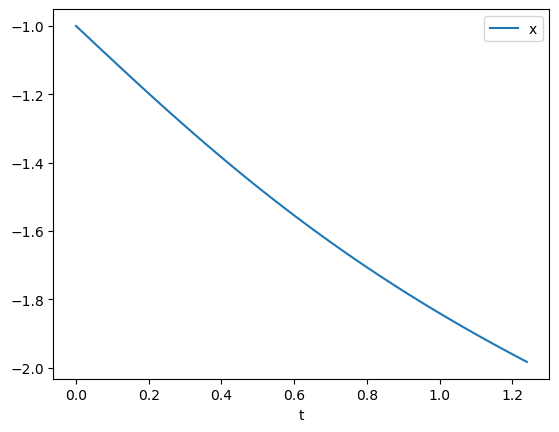

In [11]:
#df.plot('t', ['x', 'f(t)'])
df.plot('t', 'x')